In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# import drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#2.Khám phá dữ liệu - EDA
Trong phần này sẽ thực hiện các bước:
 - Đọc file dữ liệu từ Google Drive
 - Tìm hiểu tập dữ liệu thông qua các thông kê mô tả
 - Phân tích đơn biến, song biến
 - Đánh giá tương quan

##2.1 Đọc dữ liệu

In [12]:
# Thiết lập phong cách biểu đồ chuyên nghiệp
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# 1. Tải lại dữ liệu từ file CSV (để đảm bảo luồng độc lập)
df_eda = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CDC_CCI/surgery_data.csv')

##2.2 Thống kê tổng quan

In [19]:
print("--- 2.2 THỐNG KÊ TỔNG QUAN ---")
print(df_eda.info())
print("\nSố lượng dữ liệu khuyết thiếu (Missing Values) ở mỗi cột:")
print(df_eda.isnull().sum())


--- 2.2 THỐNG KÊ TỔNG QUAN ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Visit_ID        5000 non-null   object 
 1   Age             5000 non-null   int64  
 2   BMI             5000 non-null   float64
 3   ASA_Score       5000 non-null   object 
 4   Has_Diabetes    5000 non-null   int64  
 5   Has_HTN         5000 non-null   int64  
 6   Surgery_Type    5000 non-null   object 
 7   PreOp_WBC       4500 non-null   float64
 8   PreOp_Albumin   4250 non-null   float64
 9   High_Risk_Flag  5000 non-null   int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 390.8+ KB
None

Số lượng dữ liệu khuyết thiếu (Missing Values) ở mỗi cột:
Visit_ID            0
Age                 0
BMI                 0
ASA_Score           0
Has_Diabetes        0
Has_HTN             0
Surgery_Type        0
PreOp_WBC         500
PreOp_Albumin     

In [10]:
# Thống kê mô tả dữ liệu sang số:
df_eda.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,54.578200,14.707166,18.0,45.0,55.0,64.0,90.0
BMI,5000.0,23.475920,3.508437,15.0,21.1,23.4,25.9,35.9
Has_Diabetes,5000.0,0.208400,0.406205,0.0,0.0,0.0,0.0,1.0
Has_HTN,5000.0,0.292800,0.455093,0.0,0.0,0.0,1.0,1.0
PreOp_WBC,4500.0,8.081844,3.297736,3.0,5.5,8.0,10.4,20.9
PreOp_Albumin,4250.0,3.784847,0.613480,1.5,3.4,3.8,4.2,5.5
High_Risk_Flag,5000.0,0.100000,0.300030,0.0,0.0,0.0,0.0,1.0


In [23]:
# dữ liệu mẫu thông qua 10 mẫu dữ liệu đầu tiên
print("\nDữ liệu mẫu (Top 10): ")
df_eda.head(10)


Dữ liệu mẫu (Top 10): 


,Visit_ID,Age,BMI,ASA_Score,Has_Diabetes,Has_HTN,Surgery_Type,PreOp_WBC,PreOp_Albumin,High_Risk_Flag
0,SURG_00001,62,22.0,I,0,0,Chương trình,10.1,3.0,0
1,SURG_00002,52,21.9,I,0,0,Chương trình,3.7,4.4,0
2,SURG_00003,64,17.2,I,0,1,Chương trình,8.4,3.7,0
3,SURG_00004,77,22.3,I,0,1,Chương trình,4.7,2.9,0
4,SURG_00005,51,26.1,II,0,0,Chương trình,3.1,NaN,0
5,SURG_00006,51,19.0,I,0,0,Chương trình,9.4,NaN,0
6,SURG_00007,78,27.2,I,0,0,Cấp cứu,12.1,2.6,0
7,SURG_00008,66,25.2,II,0,0,Chương trình,NaN,3.0,0
8,SURG_00009,47,20.9,I,0,0,Chương trình,7.3,3.4,0
9,SURG_00010,63,23.0,II,0,0,Chương trình,4.0,3.9,0


###2.2.1 Nhận xét

**Vấn đề Missing Data (Từ hàm df.isnull().sum()):**
- PreOp_WBC thiếu khoảng 500 dòng (10%) và PreOp_Albumin thiếu khoảng 750 dòng (15%).
- Tôi không thể xóa các bệnh nhân này đi vì sẽ làm mất dữ liệu quý giá, do đó tôi buộc phải dùng thuật toán nội suy (KNN Imputer) ở bước tiếp theo.


##2.3 Phân tích Đơn biến & Song biến


--- BẮT ĐẦU VẼ BIỂU ĐỒ ---


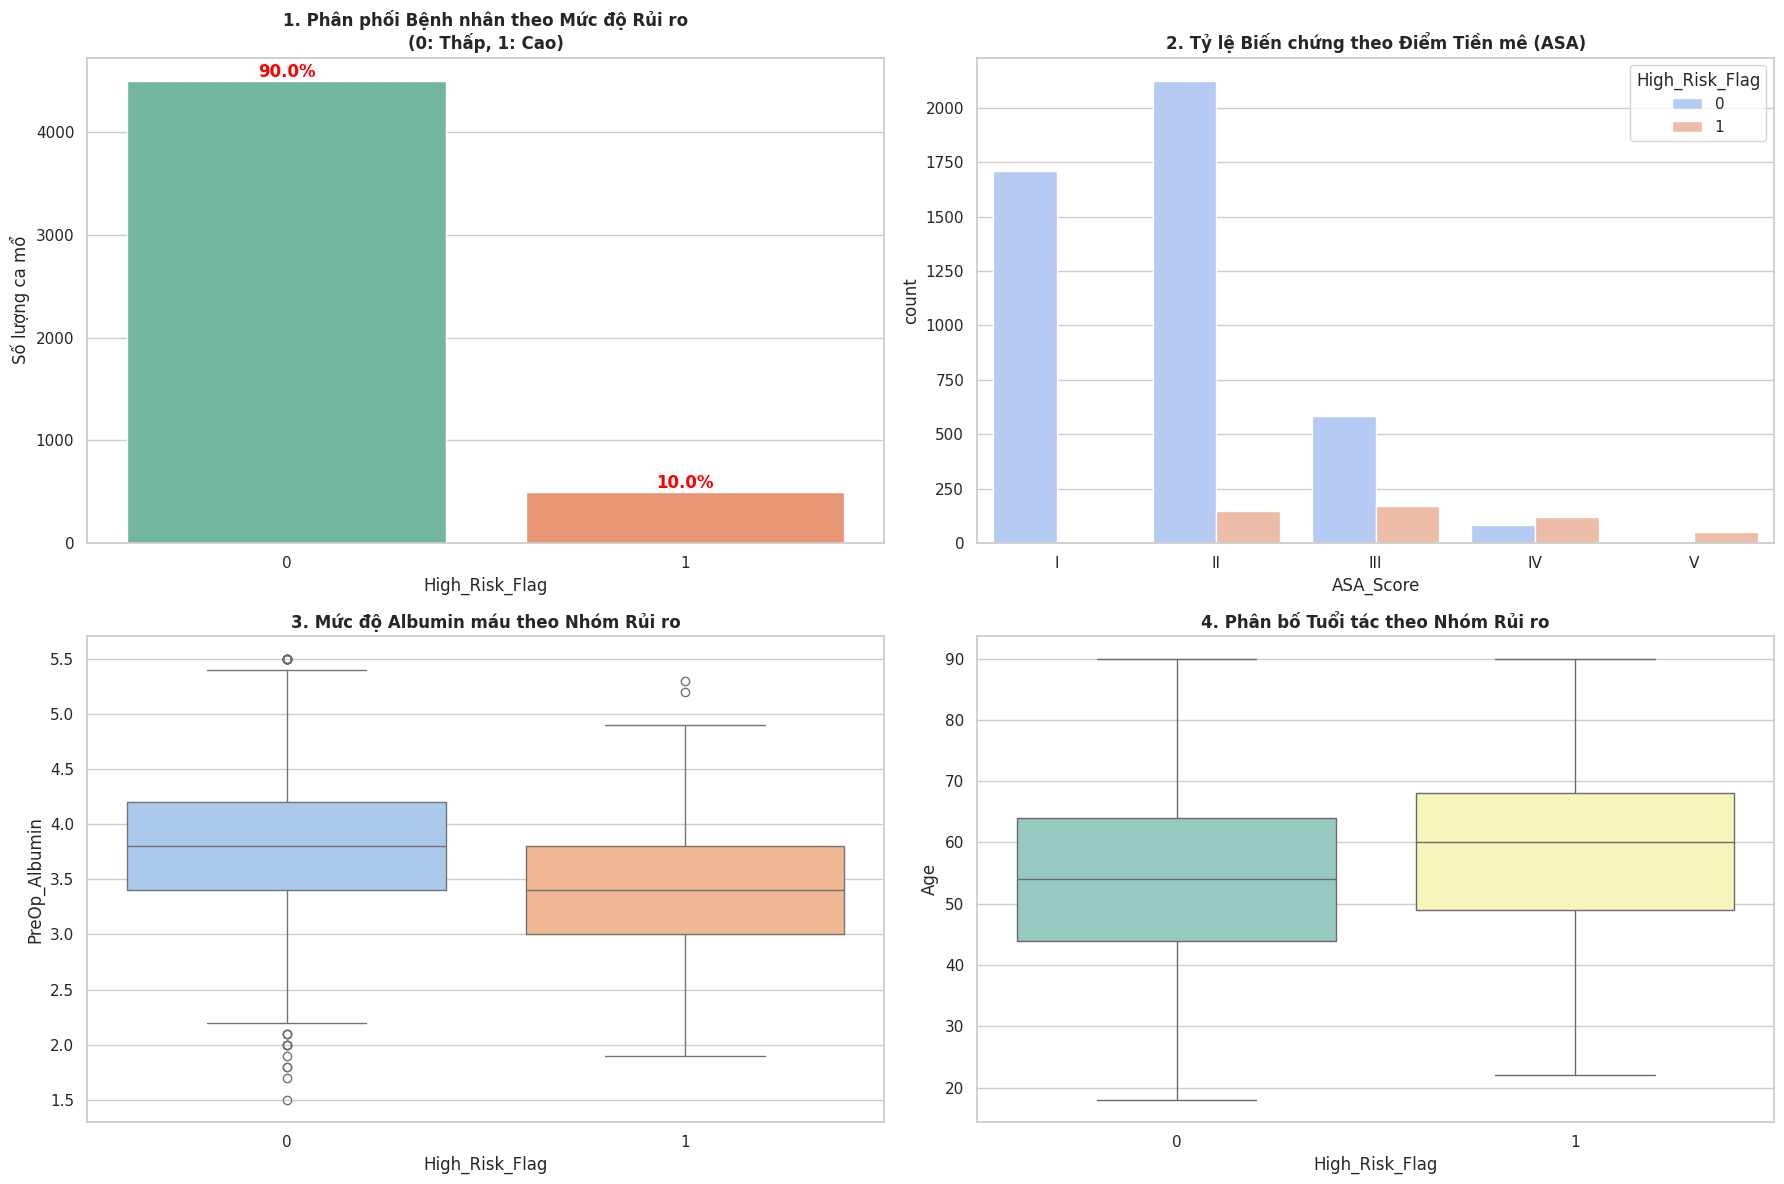

In [35]:
print("\n--- BẮT ĐẦU VẼ BIỂU ĐỒ ---")
fig = plt.figure(figsize=(18, 12))

# 2.3.1 Phân tích Đơn biến: Xem xét tỷ lệ mất cân bằng của Biến Mục Tiêu (Target)
ax1 = fig.add_subplot(2, 2, 1)
sns.countplot(data=df_eda, x='High_Risk_Flag', hue='High_Risk_Flag', palette='Set2', legend=False, ax=ax1)
ax1.set_title('1. Phân phối Bệnh nhân theo Mức độ Rủi ro\n(0: Thấp, 1: Cao)', fontweight='bold')
ax1.set_ylabel('Số lượng ca mổ')
# Thêm % vào biểu đồ
total = len(df_eda)
for p in ax1.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax1.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=12, fontweight='bold', color='red')

# 2.3.2 Phân tích Song biến: ASA Score tác động thế nào đến Rủi ro?
ax2 = fig.add_subplot(2, 2, 2)
sns.countplot(data=df_eda, x='ASA_Score', hue='High_Risk_Flag', palette='coolwarm',
              order=['I', 'II', 'III', 'IV', 'V'], ax=ax2)
ax2.set_title('2. Tỷ lệ Biến chứng theo Điểm Tiền mê (ASA)', fontweight='bold')

# 2.3.3 Phân tích Song biến: Albumin máu vs Rủi ro (Dùng Boxplot để xem phân tán)
ax3 = fig.add_subplot(2, 2, 3)
sns.boxplot(data=df_eda, x='High_Risk_Flag', hue='High_Risk_Flag', y='PreOp_Albumin', palette='pastel', legend=False, ax=ax3)
ax3.set_title('3. Mức độ Albumin máu theo Nhóm Rủi ro', fontweight='bold')

# 2.3.4 Phân tích Song biến: Tuổi tác vs Rủi ro
ax4 = fig.add_subplot(2, 2, 4)
sns.boxplot(data=df_eda, x='High_Risk_Flag', hue='High_Risk_Flag', y='Age', palette='Set3', legend=False, ax=ax4)
ax4.set_title('4. Phân bố Tuổi tác theo Nhóm Rủi ro', fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/CDC_CCI/EDA1.png')
plt.show()


### 2.3.2. Nhận xét


**Sự mất cân bằng (Biểu đồ 1):**

Cột Rủi ro cao (Nhãn 1) chỉ chiếm 10%. Điều này khẳng định sự cần thiết phải dùng kỹ thuật SMOTE mà chúng ta đã thống nhất.

**Hộp Boxplot (Biểu đồ 3 & 4):**

Nhìn vào biểu đồ Albumin, anh sẽ thấy chiếc hộp của nhóm Rủi ro cao (Nhãn 1) nằm thấp hơn hẳn so với nhóm Nhãn 0. Nghĩa là: Albumin càng thấp, rủi ro càng cao.

Ngược lại, chiếc hộp Age (Tuổi) của nhóm Nhãn 1 lại nằm cao hơn. Điều này hoàn toàn khớp với logic y khoa thực tế.


## 2.4 Đánh giá Tương quan (Correlation)

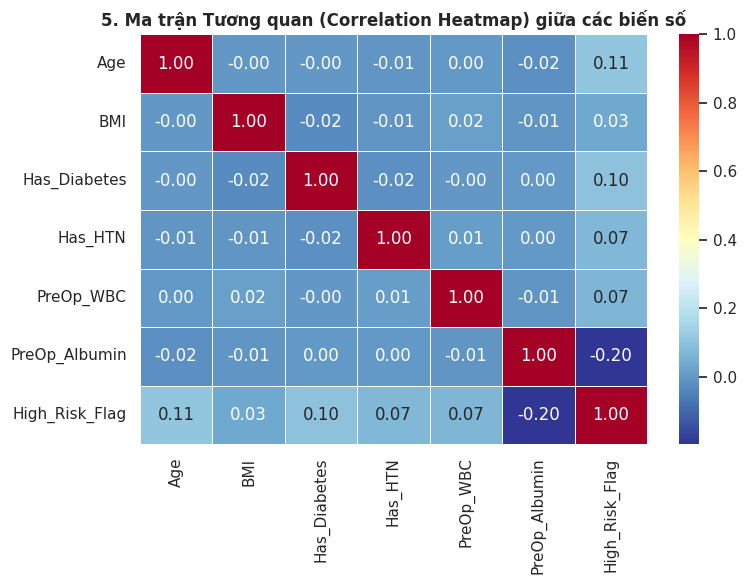

In [34]:
fig = plt.figure(figsize=(8, 6))
# 2.4 Ma trận Tương quan (Correlation Heatmap)
# Chỉ chọn các cột có giá trị số (numeric) để tính tương quan
numeric_cols = df_eda.select_dtypes(include=['float64', 'int64']).columns
# Loại bỏ cột Visit_ID (nếu có bị nhận diện nhầm là số)
if 'Visit_ID' in numeric_cols: numeric_cols = numeric_cols.drop('Visit_ID')

corr_matrix = df_eda[numeric_cols].corr()

ax5 = fig.add_subplot(1, 1, 1)
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', fmt=".2f", linewidths=.5, ax=ax5)
ax5.set_title('5. Ma trận Tương quan (Correlation Heatmap) giữa các biến số', fontweight='bold')


plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/CDC_CCI/EDA2.png')
plt.show()


###2.4. Nhận xét mối tương quan

Hãy nhìn vào dòng/cột High_Risk_Flag. Anh sẽ thấy nó có chỉ số tương quan âm với PreOp_Albumin (ví dụ: -0.35, màu xanh đậm) và tương quan dương với Age (màu đỏ).

#3.Tiền xử lý dữ liệu
Dựa vào các bước phân tích, hiểu dữ liệu (EDA) ở bước 2. Chúng ta sẽ dùng các thuất toán nội suy để điền dữ liệu cho 02 trường bị thiếu là:
PreOp_WBC thiếu khoảng 500 dòng (10%) và PreOp_Albumin thiếu khoảng 750 dòng (15%).

In [37]:
# import thêm các thư viên
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

In [39]:
# Tách cột Visit_ID ra vì AI không học từ mã bệnh án (tránh nhiễu)

visit_ids = df_eda['Visit_ID']
df_features = df_eda.drop(['Visit_ID'], axis=1)

print("\n1. Đang Mã hóa biến phân loại (Encoding)...")
# Mã hóa ASA_Score (Biến thứ bậc - Ordinal): I -> 1, II -> 2...
asa_mapping = {'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'V': 5}
df_features['ASA_Score'] = df_features['ASA_Score'].map(asa_mapping)

# Mã hóa Loại phẫu thuật (Biến nhị phân - Binary)
df_features['Surgery_Type'] = df_features['Surgery_Type'].map({'Chương trình': 0, 'Cấp cứu': 1})

print("2. Đang nội suy dữ liệu khuyết thiếu bằng KNN Imputer...")
# Lưu lại cột Target trước khi xử lý (không được phép dùng Target để nội suy X)
target_y = df_features['High_Risk_Flag']
X_features = df_features.drop('High_Risk_Flag', axis=1)

# Chạy KNN Imputer (Tìm 5 láng giềng gần nhất)
# Thuật toán bắt buộc mọi dữ liệu đưa vào phải là SỐ (đó là lý do ta phải Encoding ở bước trên)
imputer = KNNImputer(n_neighbors=5, weights='distance')
X_imputed = pd.DataFrame(imputer.fit_transform(X_features), columns=X_features.columns)

print("3. Đang Chuẩn hóa dữ liệu liên tục (Standard Scaling)...")
# Các chỉ số như Bạch cầu (4.0-10.0) và Tuổi (18-90) có thang đo khác nhau.
# Cần dùng StandardScaler ép chúng về cùng một hệ quy chiếu để mô hình học nhanh hơn.
continuous_cols = ['Age', 'BMI', 'PreOp_WBC', 'PreOp_Albumin']
scaler = StandardScaler()

X_scaled = X_imputed.copy()
X_scaled[continuous_cols] = scaler.fit_transform(X_imputed[continuous_cols])

# Ghép lại thành một DataFrame hoàn chỉnh và sạch sẽ
df_clean = pd.concat([visit_ids, X_scaled, target_y], axis=1)

print("\n--- HOÀN THÀNH TIỀN XỬ LÝ ---")
print("Kiểm tra dữ liệu khuyết thiếu sau khi chạy KNN Imputer:")
print(df_clean.isnull().sum()) # Sẽ trả về toàn bộ là 0

print("\nXem trước 5 dòng dữ liệu ĐÃ LÀM SẠCH VÀ CHUẨN HÓA:")
display(df_clean.head())

# Lưu file đã làm sạch để dùng cho Module 4
df_clean.to_csv('/content/drive/MyDrive/Colab Notebooks/CDC_CCI/surgery_data_cleaned.csv', index=False)


1. Đang Mã hóa biến phân loại (Encoding)...
2. Đang nội suy dữ liệu khuyết thiếu bằng KNN Imputer...
3. Đang Chuẩn hóa dữ liệu liên tục (Standard Scaling)...

--- HOÀN THÀNH TIỀN XỬ LÝ ---
Kiểm tra dữ liệu khuyết thiếu sau khi chạy KNN Imputer:
Visit_ID          0
Age               0
BMI               0
ASA_Score         0
Has_Diabetes      0
Has_HTN           0
Surgery_Type      0
PreOp_WBC         0
PreOp_Albumin     0
High_Risk_Flag    0
dtype: int64

Xem trước 5 dòng dữ liệu ĐÃ LÀM SẠCH VÀ CHUẨN HÓA:


,Visit_ID,Age,BMI,ASA_Score,Has_Diabetes,Has_HTN,Surgery_Type,PreOp_WBC,PreOp_Albumin,High_Risk_Flag
0,SURG_00001,0.504689,-0.420719,1.0,0.0,0.0,0.0,0.640482,-1.363766,0
1,SURG_00002,-0.175320,-0.449225,1.0,0.0,0.0,0.0,-1.377894,1.062472,0
2,SURG_00003,0.640691,-1.788987,1.0,0.0,1.0,0.0,0.104351,-0.150647,0
3,SURG_00004,1.524702,-0.335203,1.0,0.0,1.0,0.0,-1.062522,-1.537069,0
4,SURG_00005,-0.243321,0.748009,2.0,0.0,0.0,0.0,-1.567116,0.651653,0


## Nhận xét:
3 điểm chính trong luồng xử lý (Data Pipeline) này:

**Thứ tự thực hiện (Order of Execution):** Mã hóa chữ thành số (Encoding) trước khi chạy Nội suy khuyết thiếu (KNN Imputer). Lý do là thuật toán KNN tính khoảng cách dựa trên các con số. Nếu để cột ASA_Score dưới dạng chữ 'III' hoặc 'IV', KNN sẽ báo lỗi ngay lập tức vì không biết cộng trừ chữ cái.

**Không dùng biến Mục tiêu (Y) để nội suy biến Đầu vào (X):** Ở dòng code X_features = df_features.drop('High_Risk_Flag', axis=1), tôi đã tách cái nhãn Rủi ro ra khỏi tập dữ liệu đưa cho KNN Imputer. Nếu để nguyên biến Target trong lúc tìm láng giềng để điền WBC/Albumin, chúng ta đang vô tình gây ra lỗi Rò rỉ dữ liệu (Data Leakage).

**Mô hình sẽ "ăn gian" biết trước kết quả.Chuẩn hóa (Scaling):** Tuổi tác dao động từ 18-90, trong khi Albumin chỉ từ 1.5-5.5. Nếu không Scale, mô hình (đặc biệt là Logistic Regression và KNN) sẽ tưởng biến "Tuổi" quan trọng gấp mấy chục lần "Albumin" chỉ vì con số của nó to hơn.

#4.Xu lý cân bằng dữ liệu theo SMOTE

In [40]:
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

--- BẮT ĐẦU MODULE 4: CÂN BẰNG DỮ LIỆU VỚI SMOTE ---

1. Đang chia tập Train / Test (Tỷ lệ 80:20)...
   -> Số lượng tập Train ban đầu: 4000
   -> Số lượng tập Test (Giữ nguyên để thi): 1000

Phân phối nhãn tập Train ban đầu (Chưa cân bằng):
High_Risk_Flag
0    3600
1     400
Name: count, dtype: int64

2. Đang áp dụng thuật toán SMOTE CHỈ TRÊN TẬP TRAIN...

--- KẾT QUẢ SAU KHI CHẠY SMOTE ---
Số lượng tập Train MỚI: 7200
Phân phối nhãn tập Train MỚI (Đã cân bằng 50:50):
High_Risk_Flag
0    3600
1    3600
Name: count, dtype: int64


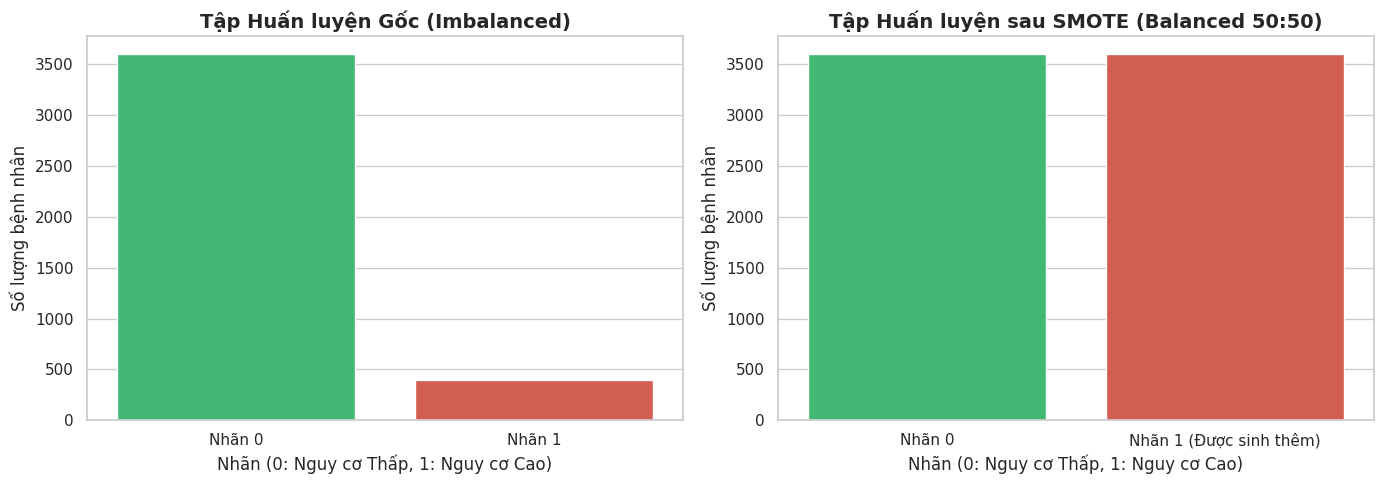

In [42]:


print("--- BẮT ĐẦU MODULE 4: CÂN BẰNG DỮ LIỆU VỚI SMOTE ---")

# 1. Load dữ liệu đã làm sạch từ Module 3
df_clean = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CDC_CCI/surgery_data_cleaned.csv')

# Tách Features (X) và Target (y)
# Bỏ cột Visit_ID ra khỏi tập X vì ID không mang ý nghĩa y khoa để dự báo
X = df_clean.drop(columns=['Visit_ID', 'High_Risk_Flag'])
y = df_clean['High_Risk_Flag']

print("\n1. Đang chia tập Train / Test (Tỷ lệ 80:20)...")
# stratify=y cực kỳ quan trọng: Ép hệ thống phải giữ đúng tỷ lệ 90/10 ở cả 2 tập
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("   -> Số lượng tập Train ban đầu:", len(X_train))
print("   -> Số lượng tập Test (Giữ nguyên để thi):", len(X_test))
print("\nPhân phối nhãn tập Train ban đầu (Chưa cân bằng):")
print(y_train.value_counts())

print("\n2. Đang áp dụng thuật toán SMOTE CHỈ TRÊN TẬP TRAIN...")
# Khởi tạo SMOTE
smote = SMOTE(random_state=42)
# Chạy SMOTE để sinh ra các "Bệnh nhân ảo" cho nhóm Nhãn 1
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n--- KẾT QUẢ SAU KHI CHẠY SMOTE ---")
print("Số lượng tập Train MỚI:", len(X_train_smote))
print("Phân phối nhãn tập Train MỚI (Đã cân bằng 50:50):")
print(y_train_smote.value_counts())

# 3. Vẽ biểu đồ so sánh trực quan (Dùng để đưa vào Slide Luận văn)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ trước SMOTE
sns.countplot(x=y_train, hue=y_train, ax=axes[0], palette=['#2ecc71', '#e74c3c'], legend=False)
axes[0].set_title('Tập Huấn luyện Gốc (Imbalanced)', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Số lượng bệnh nhân')
axes[0].set_xlabel('Nhãn (0: Nguy cơ Thấp, 1: Nguy cơ Cao)')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Nhãn 0', 'Nhãn 1'])

# Biểu đồ sau SMOTE
sns.countplot(x=y_train_smote, hue=y_train_smote, ax=axes[1], palette=['#2ecc71', '#e74c3c'], legend=False)
axes[1].set_title('Tập Huấn luyện sau SMOTE (Balanced 50:50)', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Số lượng bệnh nhân')
axes[1].set_xlabel('Nhãn (0: Nguy cơ Thấp, 1: Nguy cơ Cao)')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Nhãn 0', 'Nhãn 1 (Được sinh thêm)'])

plt.tight_layout()
plt.show()

#5.Huấn luyện mô hình
Trong phần này chúng ta sẽ huấn luyện 03 mô hình để đánh giá và lựa chọn mô hình hiệu quả nhất

--- BẮT ĐẦU MODULE 5: HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH ---
Đang cho các mô hình chạy đua trên tập Train (Đã SMOTE) và thi trên tập Test (Thực tế)...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:13:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- BẢNG XẾP HẠNG HIỆU SUẤT CÁC MÔ HÌNH ---


,Tên Mô Hình,ROC-AUC (Toàn diện),Recall (Độ nhạy - Quan trọng nhất),Precision (Độ chính xác),F1-Score
0,1. Logistic Regression (Baseline),0.937,0.83,0.441,0.576
1,3. XGBoost,0.922,0.60,0.545,0.571
2,2. Random Forest,0.921,0.62,0.602,0.611


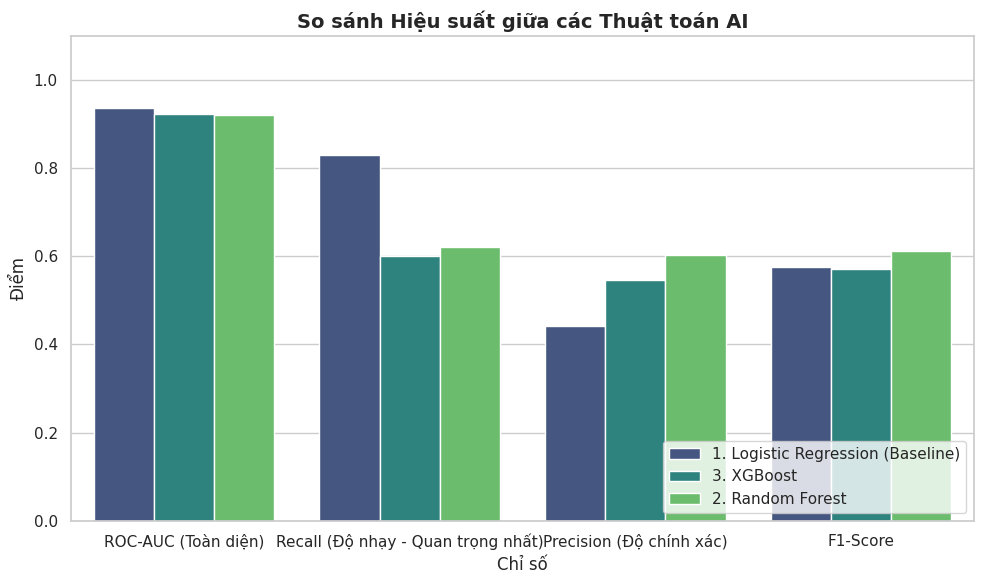

In [43]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, recall_score, precision_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

print("--- BẮT ĐẦU MODULE 5: HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH ---")

# 1. Khởi tạo 3 mô hình
# random_state=42 giúp kết quả luôn cố định trong các lần chạy
models = {
    "1. Logistic Regression (Baseline)": LogisticRegression(max_iter=2000, random_state=42),
    "2. Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "3. XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = []
predictions = {}

print("Đang cho các mô hình chạy đua trên tập Train (Đã SMOTE) và thi trên tập Test (Thực tế)...")

# 2. Vòng lặp Huấn luyện và Chấm điểm
for name, model in models.items():
    # BƯỚC QUAN TRỌNG NHẤT: Huấn luyện AI trên tập đã cân bằng (SMOTE)
    model.fit(X_train_smote, y_train_smote)

    # Dự báo nhãn (0/1) và xác suất (%) trên TẬP KIỂM THỬ GỐC
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] # Lấy xác suất của nhãn 1 (Có biến chứng)

    # Lưu lại dự báo để dùng cho biểu đồ
    predictions[name] = y_pred_proba

    # Tính toán các chỉ số đo lường (Metrics)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    recall = recall_score(y_test, y_pred)      # Tỷ lệ Bắt trúng bệnh nhân có biến chứng
    precision = precision_score(y_test, y_pred) # Tỷ lệ Báo động đúng (Không báo động giả)
    f1 = f1_score(y_test, y_pred)              # Điểm trung bình hài hòa giữa Precision và Recall

    results.append({
        "Tên Mô Hình": name,
        "ROC-AUC (Toàn diện)": round(roc_auc, 3),
        "Recall (Độ nhạy - Quan trọng nhất)": round(recall, 3),
        "Precision (Độ chính xác)": round(precision, 3),
        "F1-Score": round(f1, 3)
    })

# 3. Chuyển kết quả thành Bảng (DataFrame) và xếp hạng theo ROC-AUC
df_results = pd.DataFrame(results).sort_values(by="ROC-AUC (Toàn diện)", ascending=False).reset_index(drop=True)

print("\n--- BẢNG XẾP HẠNG HIỆU SUẤT CÁC MÔ HÌNH ---")
display(df_results)

# 4. Vẽ biểu đồ so sánh trực quan
plt.figure(figsize=(10, 6))
sns.barplot(data=pd.melt(df_results, id_vars="Tên Mô Hình", var_name="Chỉ số", value_name="Điểm"),
            x="Chỉ số", y="Điểm", hue="Tên Mô Hình", palette="viridis")
plt.title("So sánh Hiệu suất giữa các Thuật toán AI", fontweight='bold', fontsize=14)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

#6.Giải thích mô hình


In [44]:
import shap
import matplotlib.pyplot as plt
import numpy as np

--- BẮT ĐẦU MODULE 6: MỞ HỘP ĐEN AI VỚI SHAP ---

1. Đang vẽ Biểu đồ Tầm quan trọng của Đặc trưng (Summary Plot)...


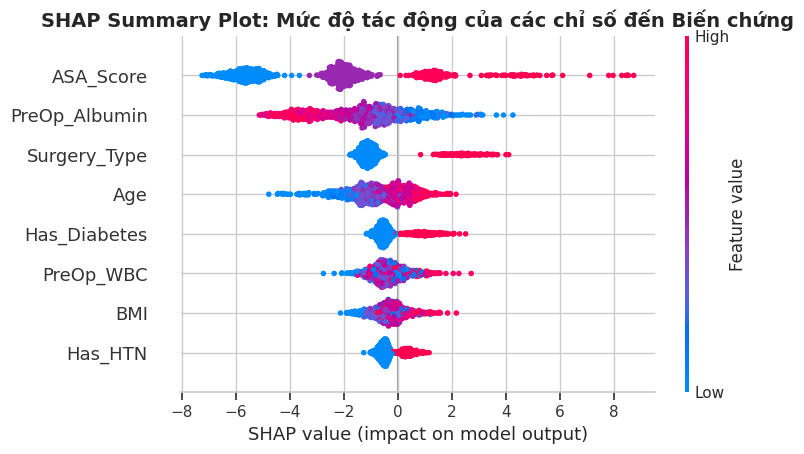


2. Đang vẽ Biểu đồ Giải thích cho 1 Bệnh nhân nguy cơ cao cụ thể (Waterfall Plot)...


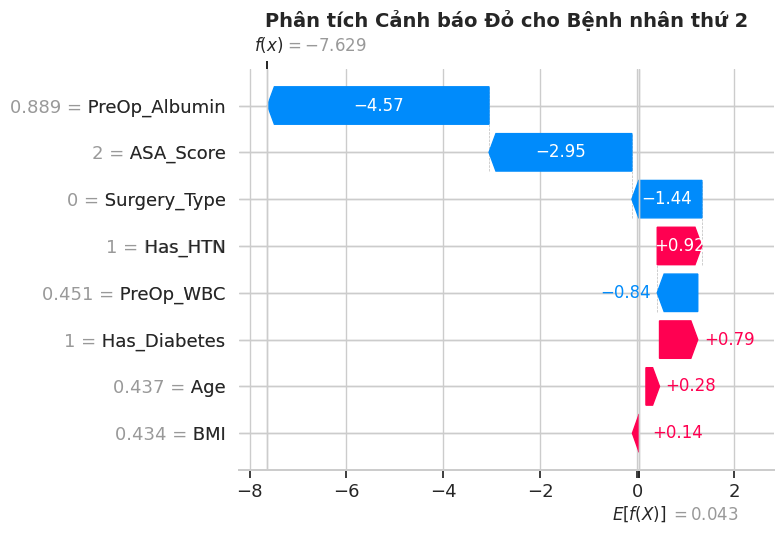

In [46]:

print("--- BẮT ĐẦU MODULE 6: MỞ HỘP ĐEN AI VỚI SHAP ---")

# 1. Lấy mô hình XGBoost đã huấn luyện từ biến 'models' ở Module 5
xgb_model = models["3. XGBoost"]

# 2. Khởi tạo SHAP Explainer (Sử dụng TreeExplainer tối ưu cho XGBoost/Random Forest)
explainer = shap.Explainer(xgb_model)

# Tính toán giá trị SHAP cho toàn bộ tập Kiểm thử (X_test)
# Lưu ý: Quá trình này có thể mất vài giây
shap_values = explainer(X_test)

# --- BIỂU ĐỒ 1: TỔNG QUAN TOÀN CỤC (GLOBAL EXPLAINABILITY) ---
print("\n1. Đang vẽ Biểu đồ Tầm quan trọng của Đặc trưng (Summary Plot)...")
plt.figure(figsize=(10, 8))
# Vẽ summary plot dạng bee swarm
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot: Mức độ tác động của các chỉ số đến Biến chứng", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# --- BIỂU ĐỒ 2: GIẢI THÍCH CÁ NHÂN (LOCAL EXPLAINABILITY) ---
print("\n2. Đang vẽ Biểu đồ Giải thích cho 1 Bệnh nhân nguy cơ cao cụ thể (Waterfall Plot)...")

# Tìm vị trí (index) của bệnh nhân đầu tiên trong tập Test thực sự BỊ BIẾN CHỨNG (Nhãn 1)
# Reset index để dễ dàng lấy iloc cho SHAP
y_test_reset = y_test.reset_index(drop=True)
patient_iloc = y_test_reset[y_test_reset == 1].index[0]

# Vẽ biểu đồ thác nước (Waterfall) cho bệnh nhân này
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_values[patient_iloc], show=False)
plt.title(f"Phân tích Cảnh báo Đỏ cho Bệnh nhân thứ {patient_iloc}", fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

##6.1 Đánh giá lại 1 ca TRUE POSITIVE

--- TÌM VÀ GIẢI THÍCH CA BỆNH TRUE POSITIVE (DỰ BÁO ĐÚNG RỦI RO CAO) ---
Đã tìm thấy ca True Positive tại vị trí index: 7
-> Thực tế: Có biến chứng (1) | AI Dự báo: Nguy cơ cao (1)


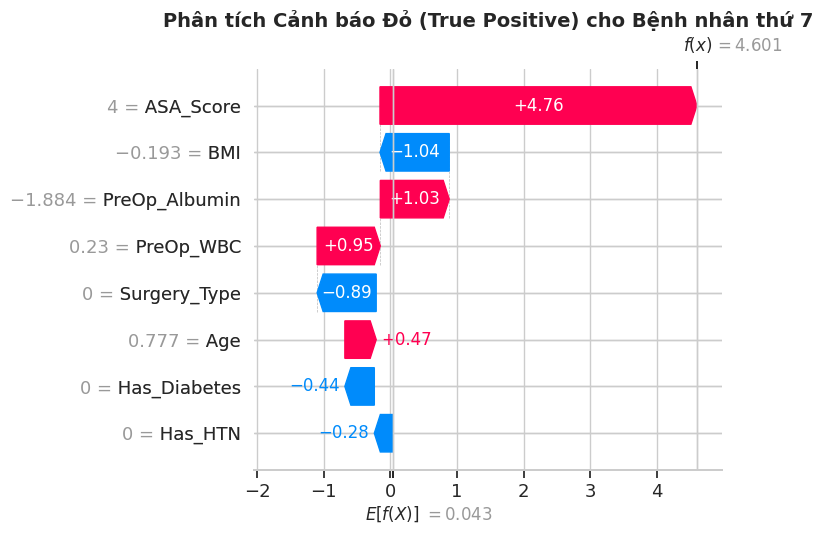

In [47]:
import matplotlib.pyplot as plt
import shap
import pandas as pd

print("--- TÌM VÀ GIẢI THÍCH CA BỆNH TRUE POSITIVE (DỰ BÁO ĐÚNG RỦI RO CAO) ---")

# 1. Lấy lại mô hình XGBoost và dự báo nhãn trên tập Test
xgb_model = models["3. XGBoost"]
y_pred_xgb = xgb_model.predict(X_test)

# Reset index để các mảng dữ liệu khớp hàng với nhau
y_test_reset = y_test.reset_index(drop=True)
y_pred_series = pd.Series(y_pred_xgb)

# 2. Lọc tìm các bệnh nhân True Positive (Thực tế = 1 VÀ Dự báo = 1)
tp_indices = y_test_reset[(y_test_reset == 1) & (y_pred_series == 1)].index

if len(tp_indices) > 0:
    # Lấy bệnh nhân True Positive đầu tiên tìm được
    patient_iloc_tp = tp_indices[0]
    print(f"Đã tìm thấy ca True Positive tại vị trí index: {patient_iloc_tp}")
    print(f"-> Thực tế: Có biến chứng (1) | AI Dự báo: Nguy cơ cao (1)")

    # 3. Vẽ biểu đồ Waterfall cho bệnh nhân này
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_values[patient_iloc_tp], show=False)
    plt.title(f"Phân tích Cảnh báo Đỏ (True Positive) cho Bệnh nhân thứ {patient_iloc_tp}", fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy ca True Positive nào trong tập Test (Hãy kiểm tra lại mô hình).")